# Parkinson's Disease Gene Expression Analysis
## Notebook 1: Data Loading

Dataset: GSE99039 (GEO)

Flow of this notebook:
- Load gene expression dataset
- Inspect structure
- Perform basic quality checks
- Visualize expression distributions
- Save clean raw dataset

Author: Athanasiadou Maria

In [1]:
# Import basic libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Path to dataset
file_path = "../data/GSE99039_series_matrix.txt.gz"

In [3]:
# Load gene expression dataset
data = pd.read_csv(
    file_path,
    sep="\t",
    comment="!",
    index_col=0,
    compression="gzip"
)

print("Dataset loaded successfully")

Dataset loaded successfully


## Step 1 - Understand the Structure

Each row (54675 rows in total) is a probe and each column is a patient sample (GSM ID) (558 samples in total).

In [4]:
# Check dataset dimensions
data.shape

(54675, 558)

In [5]:
# Preview dataset 
data.head()

,GSM2630758,GSM2630759,GSM2630760,GSM2630761,GSM2630762,GSM2630763,GSM2630764,GSM2630765,GSM2630766,GSM2630767,...,GSM2631306,GSM2631307,GSM2631308,GSM2631309,GSM2631310,GSM2631311,GSM2631312,GSM2631313,GSM2631314,GSM2631315
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.397,4.952,5.331,5.601,5.087,5.921,5.153,5.341,5.261,5.147,...,5.583,5.535,5.737,4.937,5.765,6.056,5.989,5.697,5.567,5.529
1053_at,5.199,5.198,4.970,5.816,5.443,5.430,5.243,5.167,5.324,5.489,...,5.775,5.004,5.672,5.415,5.195,5.282,5.228,5.528,5.706,5.078
117_at,8.327,8.589,8.629,9.628,9.449,9.230,9.269,9.095,9.184,8.623,...,8.426,7.061,6.771,8.691,7.073,7.325,8.567,6.844,8.511,8.458
121_at,7.042,6.935,7.701,6.909,7.284,7.153,6.850,7.541,6.918,6.714,...,7.192,7.326,7.319,6.702,7.747,7.712,7.743,7.468,7.526,7.673
1255_g_at,2.463,2.388,2.349,2.268,2.407,2.137,2.029,2.464,2.607,2.286,...,2.178,2.300,2.302,2.559,2.513,2.437,2.530,2.506,2.708,2.810


In [6]:
# Check total missing values
total_mv = data.isna().sum().sum()
print(f"Number of total missing values: {total_mv}")

Number of total missing values: 0


In [7]:
# Check data types 
data.dtypes.value_counts()

float64    558
Name: count, dtype: int64

In [8]:
# Summary statistics per sample
data.describe().round(3)

,GSM2630758,GSM2630759,GSM2630760,GSM2630761,GSM2630762,GSM2630763,GSM2630764,GSM2630765,GSM2630766,GSM2630767,...,GSM2631306,GSM2631307,GSM2631308,GSM2631309,GSM2631310,GSM2631311,GSM2631312,GSM2631313,GSM2631314,GSM2631315
count,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,...,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000,54675.000
mean,4.549,4.586,4.551,4.606,4.666,4.587,4.618,4.563,4.770,4.621,...,4.581,4.579,4.590,4.596,4.566,4.575,4.584,4.602,4.591,4.586
std,1.818,1.993,1.866,2.051,2.002,1.991,2.097,1.908,2.058,2.146,...,1.785,1.739,1.935,1.876,1.656,1.756,1.722,1.807,1.802,1.769
min,1.700,1.664,1.617,1.688,1.686,1.689,1.693,1.622,1.739,1.593,...,1.689,1.748,1.761,1.692,1.767,1.747,1.667,1.776,1.757,1.759
25%,3.141,2.984,3.063,2.950,3.069,2.979,2.899,3.040,3.111,2.845,...,3.192,3.189,3.036,3.133,3.258,3.184,3.237,3.150,3.180,3.192
50%,4.218,4.140,4.198,4.137,4.204,4.155,4.129,4.179,4.305,4.108,...,4.256,4.310,4.193,4.210,4.355,4.315,4.341,4.285,4.280,4.296
75%,5.563,5.764,5.657,5.831,5.853,5.778,5.931,5.685,6.013,5.994,...,5.589,5.620,5.723,5.630,5.579,5.619,5.604,5.682,5.611,5.603
max,14.839,14.972,14.979,14.806,14.841,14.915,14.883,14.954,14.850,14.665,...,14.882,14.875,14.891,14.896,14.920,14.954,14.941,14.898,14.931,14.902


## Step 2 - Check Expression Value Range

Microarray data is typically log2-transformed already. Values should roughly fall between 2 and 15.

In [9]:
# Minimum and maximum expression values
print("Minimum value:", data.min().min())
print("Maximum value:", data.max().max())

Minimum value: 1.455
Maximum value: 15.17


## Step 3 - Global Expression Distribution

The global distribution appears right-skewed, with most genes showing low-to-moderate expression and fewer genes exhibiting high expression levels.
This pattern is biologically expected, as most genes are expressed at low levels while a smaller subset is highly expressed.
The expression range (≈1.5–15) further supports that the dataset is likely log2-transformed.

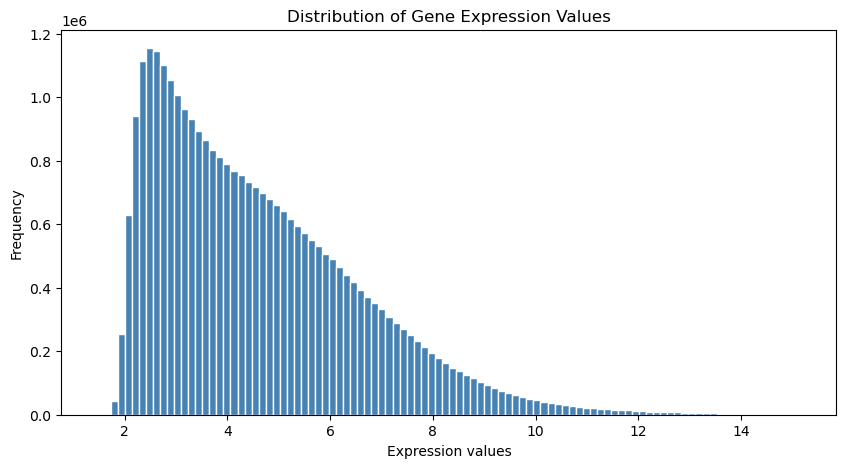

In [10]:
# Distribution of all expression values
plt.figure(figsize=(10,5))
plt.hist(data.values.flatten(),bins=100, color="steelblue", edgecolor="white")
plt.xlabel("Expression values")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Expression Values")
plt.show()

## Step 4 - Sample Distributions (Boxplot)

Each box represents one patient sample. If the boxes are roughly aligned at the same level,
the samples are well-normalized. Large shifts between samples would indicate a normalization problem.

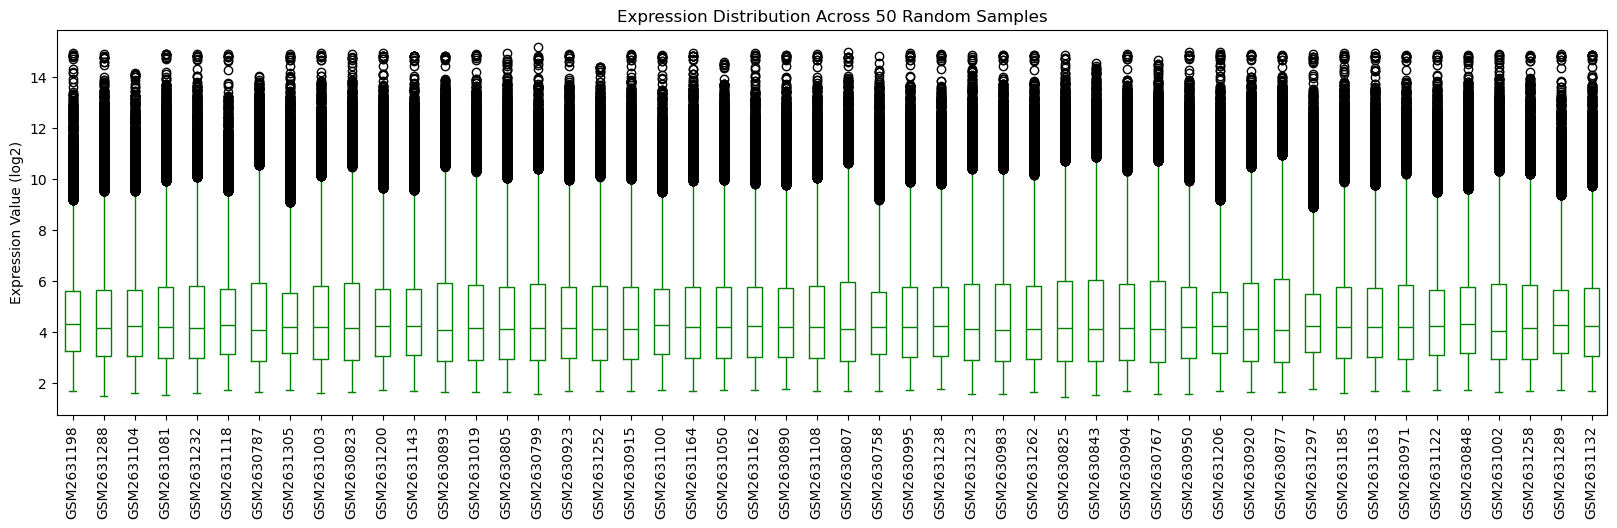

In [15]:
np.random.seed(1)
sample_cols = np.random.choice(data.columns, size=50, replace=False)
subset = data[sample_cols]

plt.figure(figsize=(20, 5))
subset.boxplot(rot=90, color="green", grid=False)
plt.ylabel("Expression Value (log2)")
plt.title("Expression Distribution Across 50 Random Samples")
plt.show()

In [16]:
# Check duplicate probes IDs
n_dup = data.index.duplicated().sum()
print(f"Number of duplicate probe IDs: {n_dup}")

Number of duplicate probe IDs: 0


## Step 5 - Save the Raw Data

In [ ]:
# Save the raw data as a compressed CSV
data.to_csv("../data/raw_expression.csv.gz", compression="gzip")
print("Raw data saved to ../data/raw_expression.csv.gz")